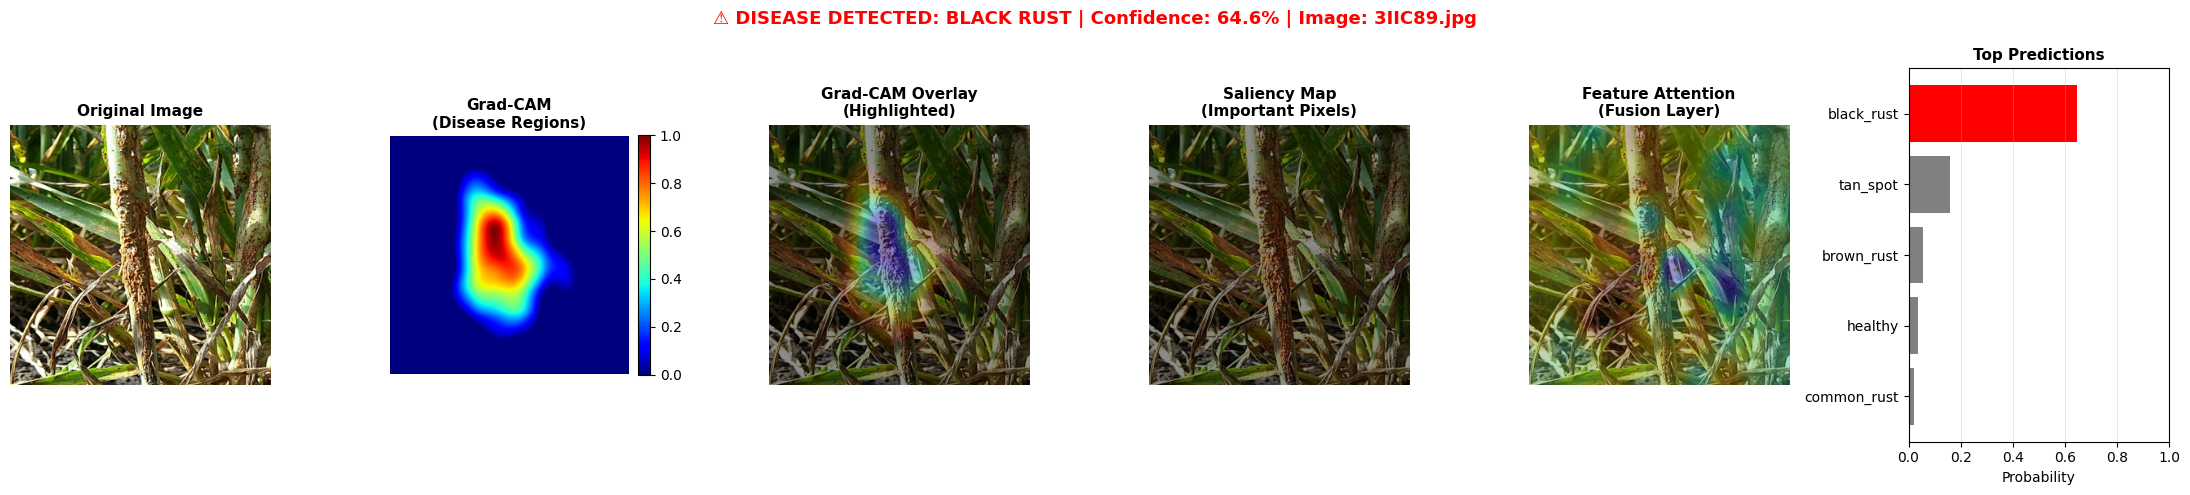

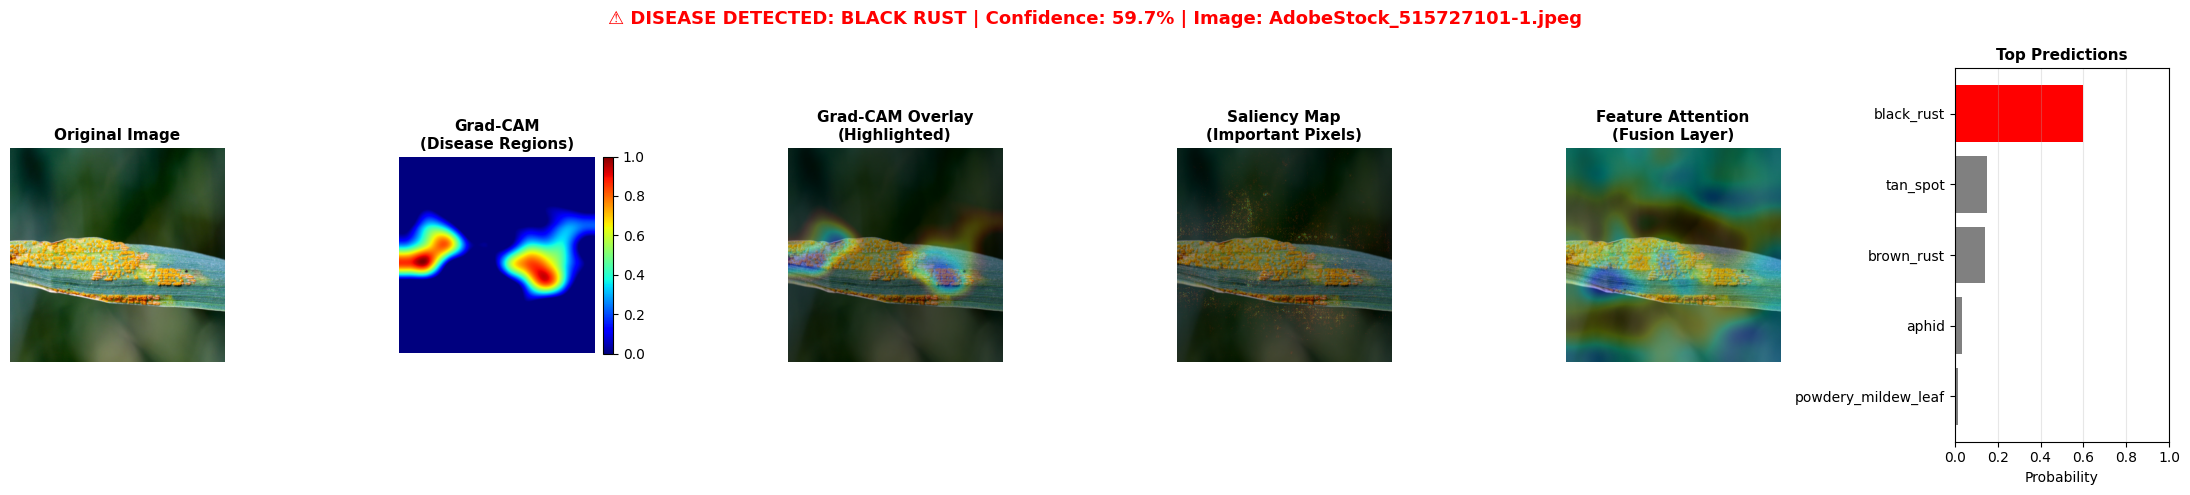

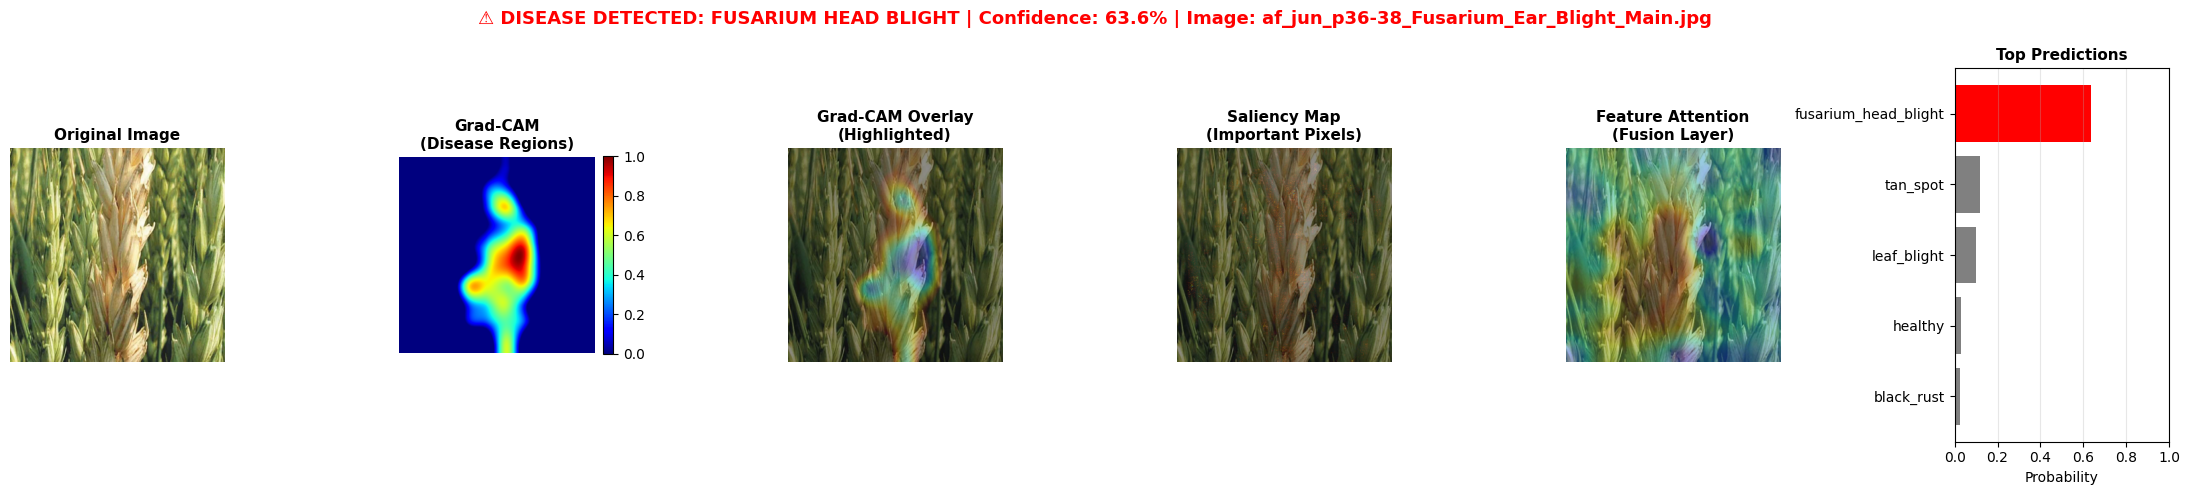

In [ ]:
import os
import torch
import torch.nn as nn
from torchvision import transforms, models
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Paths
MODEL_PATH = '../../saved_models_and_data/wheat_disease_convnext_model.pth'
LEGACY_MODEL_PATH = '../../saved_models_and_data/best_model_simple.pth'
TEST_IMAGES_DIR = '../test_images'
DATASET_DIR = '../../dataset'
IMAGE_SIZE = (320, 320)


# Class labels (dynamic loading)
def get_class_labels(dataset_dir):
    return sorted([d for d in os.listdir(dataset_dir) if os.path.isdir(os.path.join(dataset_dir, d))])

class_labels = get_class_labels(DATASET_DIR)

test_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


class MultiScaleFusion(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.branch1 = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1, groups=max(1, channels // 8)),
            nn.Conv2d(channels, channels, 1),
            nn.BatchNorm2d(channels),
            nn.GELU()
        )
        self.branch2 = nn.Sequential(
            nn.Conv2d(channels, channels, 5, padding=2, groups=max(1, channels // 8)),
            nn.Conv2d(channels, channels, 1),
            nn.BatchNorm2d(channels),
            nn.GELU()
        )
        self.branch3 = nn.Sequential(
            nn.Conv2d(channels, channels, 7, padding=3, groups=max(1, channels // 8)),
            nn.Conv2d(channels, channels, 1),
            nn.BatchNorm2d(channels),
            nn.GELU()
        )
        self.fusion = nn.Sequential(
            nn.Conv2d(channels * 3, channels, 1),
            nn.BatchNorm2d(channels)
        )

    def forward(self, x):
        f1 = self.branch1(x)
        f2 = self.branch2(x)
        f3 = self.branch3(x)
        concat = torch.cat([f1, f2, f3], dim=1)
        return self.fusion(concat)


def build_model(num_classes):
    model = models.convnext_base(weights=None)
    in_features = model.classifier[2].in_features
    model.fusion = MultiScaleFusion(in_features)
    model.classifier = nn.Sequential(
        nn.AdaptiveAvgPool2d(1),
        nn.Flatten(),
        nn.LayerNorm(in_features),
        nn.Dropout(0.2),
        nn.Linear(in_features, 768),
        nn.GELU(),
        nn.Dropout(0.3),
        nn.Linear(768, 384),
        nn.GELU(),
        nn.Dropout(0.2),
        nn.Linear(384, num_classes)
    )

    def forward(x):
        x = model.features(x)
        x = model.fusion(x)
        x = model.classifier(x)
        return x

    model.forward = forward
    return model


def load_checkpoint(model, device):
    checkpoint_path = MODEL_PATH if os.path.exists(MODEL_PATH) else LEGACY_MODEL_PATH
    if checkpoint_path == LEGACY_MODEL_PATH and not os.path.exists(checkpoint_path):
        raise FileNotFoundError(f"No checkpoint found at {MODEL_PATH} or {LEGACY_MODEL_PATH}")
    if checkpoint_path == LEGACY_MODEL_PATH:
        print(f"⚠️ Using legacy checkpoint: {LEGACY_MODEL_PATH}")
    state_dict = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(state_dict)
    return model


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = build_model(len(class_labels))
model = load_checkpoint(model, device)
model = model.to(device)
model.eval()

class GradCAM:
    """Improved Grad-CAM for accurate disease spot highlighting"""
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.hook_handles = []
        self._register_hooks()
    
    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()
        
        def backward_hook(module, grad_in, grad_out):
            # Handle cases where grad_out might be None or tuple
            if grad_out[0] is not None:
                self.gradients = grad_out[0].detach()
            else:
                self.gradients = None
        
        self.hook_handles.append(self.target_layer.register_forward_hook(forward_hook))
        self.hook_handles.append(self.target_layer.register_full_backward_hook(backward_hook))
    
    def __call__(self, input_tensor, class_idx=None, threshold_percentile=75):
        self.model.zero_grad()
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
        
        loss = output[0, class_idx]
        loss.backward()
        
        if self.gradients is None:
            # Fallback: create zero gradients
            self.gradients = torch.zeros_like(self.activations)
        
        gradients = self.gradients[0]
        activations = self.activations[0]
        
        # Improved weight computation: use global average pooling with ReLU
        weights = torch.relu(gradients).mean(dim=(1, 2))
        
        # Weighted combination of activations
        cam = (weights[:, None, None] * activations).sum(dim=0)
        cam = torch.relu(cam)
        cam = cam.cpu().numpy()
        
        # Resize to original image size
        cam = cv2.resize(cam, IMAGE_SIZE, interpolation=cv2.INTER_CUBIC)
        
        # Improved normalization with thresholding for better focus
        cam_min, cam_max = cam.min(), cam.max()
        if cam_max > cam_min:
            cam = (cam - cam_min) / (cam_max - cam_min + 1e-8)
            # Apply threshold to focus on high-activation regions
            threshold = np.percentile(cam, threshold_percentile)
            cam = np.clip((cam - threshold) / (1 - threshold + 1e-8), 0, 1)
        else:
            cam = np.zeros_like(cam)
        
        return cam
    
    def remove_hooks(self):
        for handle in self.hook_handles:
            handle.remove()


def compute_saliency_map(model, input_tensor, class_idx=None, threshold_percentile=70):
    """Improved saliency map computation"""
    input_tensor = input_tensor.clone().detach().requires_grad_(True)
    model.zero_grad()
    output = model(input_tensor)
    if class_idx is None:
        class_idx = output.argmax(dim=1).item()
    
    loss = output[0, class_idx]
    loss.backward()
    
    # Get gradients and compute saliency
    saliency = input_tensor.grad.data.abs().squeeze().cpu().numpy()
    saliency = np.max(saliency, axis=0)
    
    # Resize with better interpolation
    saliency = cv2.resize(saliency, IMAGE_SIZE, interpolation=cv2.INTER_CUBIC)
    
    # Normalize with thresholding
    sal_min, sal_max = saliency.min(), saliency.max()
    if sal_max > sal_min:
        saliency = (saliency - sal_min) / (sal_max - sal_min + 1e-8)
        # Apply threshold to focus on important regions
        threshold = np.percentile(saliency, threshold_percentile)
        saliency = np.clip((saliency - threshold) / (1 - threshold + 1e-8), 0, 1)
    else:
        saliency = np.zeros_like(saliency)
    
    return saliency


def compute_attention_map(model, input_tensor):
    """Feature attention map from fusion layer"""
    with torch.no_grad():
        features = None
        def hook_fn(module, input, output):
            nonlocal features
            features = output.detach()
        
        # Use fusion layer for better disease-specific features
        handle = model.fusion.register_forward_hook(hook_fn)
        _ = model(input_tensor)
        handle.remove()
        
        if features is not None:
            attn_map = features.mean(dim=1).squeeze().cpu().numpy()
            attn_map = cv2.resize(attn_map, IMAGE_SIZE, interpolation=cv2.INTER_CUBIC)
            attn_min, attn_max = attn_map.min(), attn_map.max()
            if attn_max > attn_min:
                attn_map = (attn_map - attn_min) / (attn_max - attn_min + 1e-8)
            else:
                attn_map = np.zeros_like(attn_map)
        else:
            attn_map = np.zeros(IMAGE_SIZE)
        
        return attn_map


def show_cam_on_image(img: np.ndarray, mask: np.ndarray, alpha=0.4, colormap=cv2.COLORMAP_JET):
    """Improved overlay with better blending for disease visualization"""
    # Use HOT colormap for disease (red/yellow) or JET for general
    heatmap = cv2.applyColorMap(np.uint8(255 * mask), colormap)
    heatmap = np.float32(heatmap) / 255.0
    
    # Better blending: emphasize disease regions
    # Use alpha blending with enhanced contrast for disease spots
    enhanced_mask = np.power(mask, 0.7)  # Gamma correction for better visibility
    heatmap_weighted = heatmap * enhanced_mask[:, :, np.newaxis]
    
    # Blend with original image
    img_float = np.float32(img)
    cam = (1 - alpha) * img_float + alpha * heatmap_weighted
    cam = np.clip(cam, 0, 1)
    
    return np.uint8(255 * cam)


# Use fusion layer for better disease-specific feature extraction
target_layer = model.fusion
gradcam = GradCAM(model, target_layer)
for img_name in os.listdir(TEST_IMAGES_DIR):
    if not img_name.lower().endswith(('.png', '.jpg', '.jpeg', '.webp')):
        continue
    
    img_path = os.path.join(TEST_IMAGES_DIR, img_name)
    img_pil = Image.open(img_path).convert('RGB')
    img_tensor = test_transform(img_pil).unsqueeze(0).to(device)
    
    # Get prediction
    with torch.no_grad():
        output = model(img_tensor)
        pred_idx = output.argmax(dim=1).item()
        pred_label = class_labels[pred_idx]
        prob = torch.softmax(output, dim=1)[0, pred_idx].item()
    
    img_np = np.array(img_pil.resize(IMAGE_SIZE)).astype(np.float32) / 255.0
    
    # Skip Grad-CAM and heatmaps for "healthy" class
    is_healthy = pred_label.lower() == 'healthy'
    
    if is_healthy:
        # For healthy images, just show original and prediction info
        all_probs = torch.softmax(output, dim=1)[0].cpu().numpy()
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(img_pil.resize(IMAGE_SIZE))
        plt.title(f'Original Image\n{img_name}', fontsize=12, fontweight='bold')
        plt.axis('off')
        
        plt.subplot(1, 2, 2)
        # Show top predictions
        top_k = min(5, len(class_labels))
        top_indices = np.argsort(all_probs)[-top_k:][::-1]
        top_labels = [class_labels[i] for i in top_indices]
        top_probs = [all_probs[i] for i in top_indices]
        
        colors = ['green' if label == pred_label else 'gray' for label in top_labels]
        bars = plt.barh(range(len(top_labels)), top_probs, color=colors)
        plt.yticks(range(len(top_labels)), top_labels)
        plt.xlabel('Probability', fontsize=11)
        plt.title(f'Prediction: {pred_label.upper()}\nConfidence: {prob:.1%}', 
                 fontsize=12, fontweight='bold')
        plt.xlim(0, 1)
        plt.gca().invert_yaxis()
        plt.grid(axis='x', alpha=0.3)
        
        plt.suptitle(f'✓ HEALTHY - No Disease Detected', 
                    fontsize=14, fontweight='bold', color='green')
        plt.tight_layout()
        plt.show()
    else:
        # For disease images, compute all heatmaps
        # Use JET colormap for true Grad-CAM visualization (blue to red spectrum)
        cam = gradcam(img_tensor, class_idx=pred_idx, threshold_percentile=75)
        saliency = compute_saliency_map(model, img_tensor, class_idx=pred_idx, threshold_percentile=70)
        attn_map = compute_attention_map(model, img_tensor)
        
        # Create overlays with JET colormap for true Grad-CAM (traditional blue to red)
        cam_img = show_cam_on_image(img_np, cam, alpha=0.45, colormap=cv2.COLORMAP_JET)
        sal_img = show_cam_on_image(img_np, saliency, alpha=0.45, colormap=cv2.COLORMAP_JET)
        attn_img = show_cam_on_image(img_np, attn_map, alpha=0.4, colormap=cv2.COLORMAP_JET)
        
        # Create visualization
        fig = plt.figure(figsize=(22, 5))
        
        # Original image
        plt.subplot(1, 6, 1)
        plt.imshow(img_pil.resize(IMAGE_SIZE))
        plt.title('Original Image', fontsize=11, fontweight='bold')
        plt.axis('off')
        
        # Grad-CAM heatmap (JET colormap - true Grad-CAM)
        plt.subplot(1, 6, 2)
        plt.imshow(cam, cmap='jet', vmin=0, vmax=1)
        plt.title('Grad-CAM\n(Disease Regions)', fontsize=11, fontweight='bold')
        plt.axis('off')
        plt.colorbar(fraction=0.046, pad=0.04)
        
        # Grad-CAM overlay
        plt.subplot(1, 6, 3)
        plt.imshow(cam_img)
        plt.title('Grad-CAM Overlay\n(Highlighted)', fontsize=11, fontweight='bold')
        plt.axis('off')
        
        # Saliency overlay
        plt.subplot(1, 6, 4)
        plt.imshow(sal_img)
        plt.title('Saliency Map\n(Important Pixels)', fontsize=11, fontweight='bold')
        plt.axis('off')
        
        # Attention overlay
        plt.subplot(1, 6, 5)
        plt.imshow(attn_img)
        plt.title('Feature Attention\n(Fusion Layer)', fontsize=11, fontweight='bold')
        plt.axis('off')
        
        # Prediction info
        plt.subplot(1, 6, 6)
        # Show top predictions
        all_probs = torch.softmax(output, dim=1)[0].cpu().numpy()
        top_k = min(5, len(class_labels))
        top_indices = np.argsort(all_probs)[-top_k:][::-1]
        top_labels = [class_labels[i] for i in top_indices]
        top_probs = [all_probs[i] for i in top_indices]
        
        colors = ['red' if label == pred_label else 'gray' for label in top_labels]
        bars = plt.barh(range(len(top_labels)), top_probs, color=colors)
        plt.yticks(range(len(top_labels)), top_labels)
        plt.xlabel('Probability', fontsize=10)
        plt.title(f'Top Predictions', fontsize=11, fontweight='bold')
        plt.xlim(0, 1)
        plt.gca().invert_yaxis()
        plt.grid(axis='x', alpha=0.3)
        
        # Main title
        plt.suptitle(f'⚠️ DISEASE DETECTED: {pred_label.upper().replace("_", " ")} | Confidence: {prob:.1%} | Image: {img_name}', 
                    fontsize=13, fontweight='bold', color='red')
        plt.tight_layout()
        plt.show()
    
    # Clean up hooks after each image to prevent memory issues
    gradcam.remove_hooks()
    gradcam = GradCAM(model, target_layer)
